## Pre-processing & Feature Engineering: E-Commerce Customer Behavior
**Role:** Data Engineer (Ibnu Dwiki Hermawan)

**Tujuan Notebook:**

1. Membersihkan data mentah dari *missing values* dan anomali transaksi.
2. Mengekstrak fitur RFM dan fitur tambahan (`AvgSpending`, `UniqueProducts`, `AvgMonthlySpending`, `CancelFrequency`).
3. Melakukan transformasi log dan standarisasi skala **dalam urutan yang benar** sebelum masuk ke pemodelan.
4. Menggunakan DBSCAN (dengan parameter optimal dari grid search) untuk menyaring *noise* / *outliers*.
5. Memvisualisasikan distribusi dan struktur data melalui EDA.
6. Melakukan profiling persona pada pelanggan anomali untuk insight bisnis.

---
**Perbaikan dari versi sebelumnya:**
- [FIX] Urutan operasi diperbaiki: `log1p` → `StandardScaler` (hanya 1x, tidak ganda)
- [FIX] Heatmap korelasi kini dibuat **setelah** log-transform (representasi akurat)
- [FIX] DBSCAN final kini menggunakan `best_eps` & `best_min_samples` dari grid search
- [FIX] K-Distance graph dipindahkan **sebelum** grid search sebagai panduan visual
- [ADD] Validasi post-filtering: perbandingan distribusi `clean_data` vs `noise_data`
- [ADD] Skewness sebelum vs sesudah transformasi ditampilkan dalam satu tabel perbandingan
- [ADD] Komentar justifikasi threshold pada anomaly profiling

In [24]:
# ============================================================
# Import library esensial
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

print("Library berhasil diimport.")

Library berhasil diimport.


In [25]:
# Memuat dataset
# Pastikan path disesuaikan dengan struktur repositori
file_path = '../data/raw/data.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

print(f"Dimensi data awal : {df.shape}")
print(f"Kolom             : {list(df.columns)}")
print(f"Missing values    :\n{df.isnull().sum()}")
df.head()

Dimensi data awal : (541909, 8)
Kolom             : ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Missing values    :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 1. Data Cleaning

Langkah-langkah pembersihan:
1. Hapus baris tanpa `CustomerID` (tidak bisa di-track ke pelanggan manapun)
2. Filter `StockCode` hanya untuk produk nyata (format 5-digit angka) — menghilangkan kode internal seperti `POST`, `DOT`, `AMAZONFEE`, `CRUK`, dll.
3. Buat kolom `TotalPrice` = `Quantity × UnitPrice`

> **Catatan:** Transaksi pembatalan (prefix `C`) **tidak dihapus** di tahap ini karena akan diekstrak sebagai fitur `CancelFrequency` di tahap berikutnya.

In [26]:
# --- Step 1: Hapus CustomerID kosong ---
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['InvoiceNo']  = df_clean['InvoiceNo'].astype(str)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

n_before = len(df)
n_after_cid = len(df_clean)

# --- Step 2: Filter StockCode produk nyata (>= 5 digit angka) ---
df_clean = df_clean[df_clean['StockCode'].str.contains(r'^\d{5}', na=False, regex=True)]
n_after_stock = len(df_clean)

# --- Step 3: Buat TotalPrice ---
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("=== Ringkasan Data Cleaning ===")
print(f"  Baris awal               : {n_before:>8,}")
print(f"  Setelah hapus null CustID: {n_after_cid:>8,}  (dihapus: {n_before - n_after_cid:,})")
print(f"  Setelah filter StockCode : {n_after_stock:>8,}  (dihapus: {n_after_cid - n_after_stock:,})")
print(f"  Total baris dihapus      : {n_before - n_after_stock:>8,} ({(n_before - n_after_stock)/n_before*100:.1f}%)")

=== Ringkasan Data Cleaning ===
  Baris awal               :  541,909
  Setelah hapus null CustID:  406,829  (dihapus: 135,080)
  Setelah filter StockCode :  404,909  (dihapus: 1,920)
  Total baris dihapus      :  137,000 (25.3%)


## 2. Feature Engineering (RFM + Fitur Tambahan)

Fitur yang diekstrak:

| Fitur | Deskripsi | Sumber |
|---|---|---|
| `Recency` | Jumlah hari sejak transaksi terakhir | RFM Standard |
| `Frequency` | Jumlah invoice unik (transaksi sukses) | RFM Standard |
| `Monetary` | Total pengeluaran selama periode | RFM Standard |
| `AvgSpending` | Rata-rata pengeluaran per item transaksi | Tambahan |
| `UniqueProducts` | Jumlah produk berbeda yang pernah dibeli | Tambahan |
| `CancelFrequency` | Jumlah invoice yang dibatalkan | Tambahan |
| `AvgMonthlySpending` | Rata-rata belanja per bulan aktif | Tambahan (orisinal) |

> **Justifikasi `CancelFrequency`:** Dihitung dari `df_clean` (sebelum filter sukses) karena kita memang ingin menangkap *perilaku pembatalan* pelanggan — data ini tidak akan ada jika dihitung dari `df_success`. Ini adalah fitur behavioral yang valid, bukan kebocoran data.

In [27]:
# --- Ekstraksi CancelFrequency dari df_clean (sebelum filter sukses) ---
# Justifikasi: kita ingin menangkap perilaku pembatalan tiap pelanggan.
# df_clean masih mengandung baris cancel (prefix 'C'), sehingga ini adalah
# sumber yang tepat untuk fitur ini.
df_clean['IsCanceled'] = df_clean['InvoiceNo'].str.startswith('C')
cancellations = (
    df_clean[df_clean['IsCanceled']]
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index()
    .rename(columns={'InvoiceNo': 'CancelFrequency'})
)

# --- Filter ke transaksi sukses untuk RFM utama ---
df_success = df_clean[(~df_clean['IsCanceled']) & (df_clean['Quantity'] > 0)].copy()
snapshot_date = df_success['InvoiceDate'].max() + timedelta(days=1)

# --- Agregasi RFM + fitur tambahan ---
customer_df = df_success.groupby('CustomerID').agg(
    Recency        = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency      = ('InvoiceNo',    'nunique'),
    Monetary       = ('TotalPrice',   'sum'),
    AvgSpending    = ('TotalPrice',   'mean'),
    UniqueProducts = ('StockCode',    'nunique'),
    FirstPurchase  = ('InvoiceDate',  'min'),
    LastPurchase   = ('InvoiceDate',  'max')
).reset_index()

# --- Gabungkan CancelFrequency ---
customer_df = customer_df.merge(cancellations, on='CustomerID', how='left')
customer_df['CancelFrequency'] = customer_df['CancelFrequency'].fillna(0)

# --- Hitung AvgMonthlySpending ---
customer_df['CustomerAgeMonths'] = (
    (customer_df['LastPurchase'] - customer_df['FirstPurchase']).dt.days / 30
).clip(lower=1)  # minimal 1 bulan agar tidak divide-by-zero
customer_df['AvgMonthlySpending'] = customer_df['Monetary'] / customer_df['CustomerAgeMonths']

# --- Bersihkan kolom sementara ---
customer_df = customer_df.drop(columns=['FirstPurchase', 'LastPurchase', 'CustomerAgeMonths'])
customer_df = customer_df.set_index('CustomerID')

print(f"Jumlah pelanggan unik : {len(customer_df):,}")
print(f"Fitur yang diekstrak  : {list(customer_df.columns)}")
print(f"\nStatistik deskriptif (nilai mentah):")
customer_df.describe().round(2)

Jumlah pelanggan unik : 4,335
Fitur yang diekstrak  : ['Recency', 'Frequency', 'Monetary', 'AvgSpending', 'UniqueProducts', 'CancelFrequency', 'AvgMonthlySpending']

Statistik deskriptif (nilai mentah):


,Recency,Frequency,Monetary,AvgSpending,UniqueProducts,CancelFrequency,AvgMonthlySpending
count,4335.00,4335.00,4335.00,4335.00,4335.00,4335.00,4335.00
mean,92.68,4.25,2021.01,67.94,61.41,0.77,440.23
std,100.17,7.64,8906.53,1468.61,85.30,1.97,1622.88
min,1.00,1.00,0.00,0.00,1.00,0.00,0.00
25%,18.00,1.00,305.41,12.24,16.00,0.00,132.67
50%,51.00,2.00,668.11,17.56,35.00,0.00,241.06
75%,143.00,5.00,1631.48,24.61,77.00,1.00,420.54
max,374.00,206.00,279138.02,77183.60,1785.00,45.00,77183.60


## 3. Transformasi & Scaling

**Urutan operasi yang benar (diperbaiki dari versi sebelumnya):**

```
customer_df (raw)
    ↓  [1] Cek skewness raw
    ↓  [2] Log1p transform  →  customer_df_log
    ↓  [3] Cek skewness post-log + heatmap korelasi  ← dibuat dari data log, bukan raw
    ↓  [4] StandardScaler  →  scaled_df  ← SATU KALI scaling
```

> **Mengapa Log1p?** Data e-commerce sangat *right-skewed* — sedikit pelanggan VIP dengan Monetary sangat besar mendistorsi distribusi. Log1p menekan skewness tanpa membuang data, dan aman untuk nilai 0 (`log1p(0) = 0`).

In [28]:
# ============================================================
# [1] Cek skewness SEBELUM transformasi
# ============================================================
skewness_before = customer_df.skew().round(3)

# ============================================================
# [2] Log1p Transform
# Clip lower=0 untuk handle nilai negatif edge-case (misal AvgSpending
# dari transaksi yang memiliki return parsial)
# ============================================================
customer_df_log = np.log1p(customer_df.clip(lower=0))

# ============================================================
# [3] Cek skewness SETELAH log-transform
# ============================================================
skewness_after = customer_df_log.skew().round(3)

# Tampilkan perbandingan skewness dalam satu tabel
skew_comparison = pd.DataFrame({
    'Skewness (Raw)': skewness_before,
    'Skewness (Log1p)': skewness_after,
    'Reduksi': (skewness_before - skewness_after).round(3)
})
print("=== Perbandingan Skewness Sebelum vs Sesudah Log1p ===")
print(skew_comparison.to_string())
print(f"\nCatatan: Skewness ideal mendekati 0. Nilai |skew| < 1 dianggap dapat diterima.")

=== Perbandingan Skewness Sebelum vs Sesudah Log1p ===
                    Skewness (Raw)  Skewness (Log1p)  Reduksi
Recency                      1.243            -0.378    1.621
Frequency                   11.948             1.214   10.734
Monetary                    19.566             0.363   19.203
AvgSpending                 46.466             1.600   44.866
UniqueProducts               6.918            -0.245    7.163
CancelFrequency              9.182             1.661    7.521
AvgMonthlySpending          30.746             0.276   30.470

Catatan: Skewness ideal mendekati 0. Nilai |skew| < 1 dianggap dapat diterima.


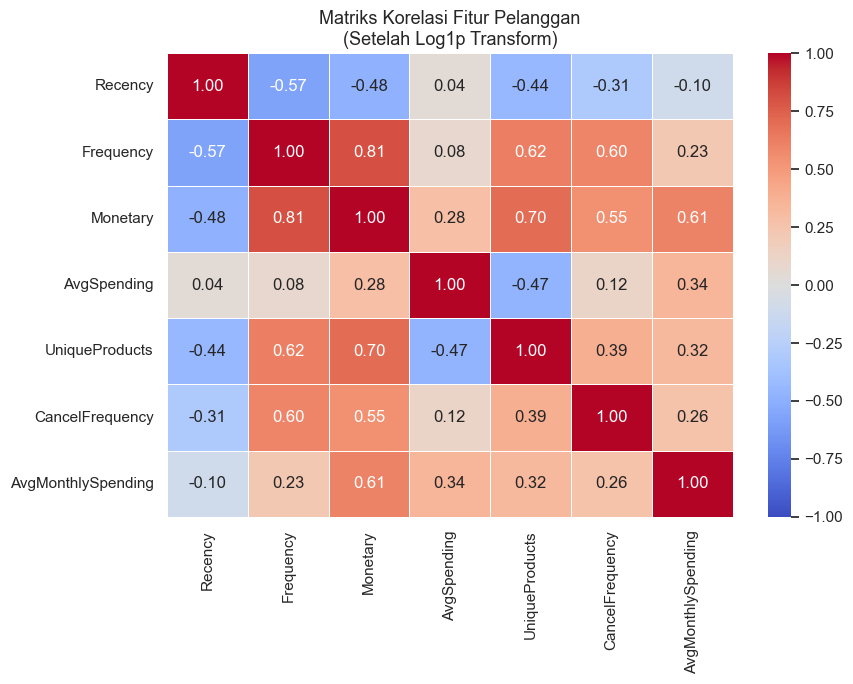

Pasangan fitur dengan korelasi tinggi (|r| > 0.6):
  Frequency              <-> Monetary                r = 0.807
  Monetary               <-> UniqueProducts          r = 0.698
  Frequency              <-> UniqueProducts          r = 0.621
  AvgMonthlySpending     <-> Monetary                r = 0.609


In [29]:
# ============================================================
# Heatmap Korelasi — dibuat dari data SETELAH log-transform
# (representasi yang akan digunakan model, bukan data raw)
# ============================================================
plt.figure(figsize=(9, 7))
sns.heatmap(
    customer_df_log.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Matriks Korelasi Fitur Pelanggan\n(Setelah Log1p Transform)', fontsize=13)
plt.tight_layout()
plt.show()

# Highlight korelasi tinggi (|r| > 0.6) sebagai catatan untuk modeling
corr_matrix = customer_df_log.corr().abs()
high_corr = [
    (i, j, corr_matrix.loc[i, j])
    for i in corr_matrix.columns
    for j in corr_matrix.columns
    if i < j and corr_matrix.loc[i, j] > 0.6
]
if high_corr:
    print("Pasangan fitur dengan korelasi tinggi (|r| > 0.6):")
    for a, b, r in sorted(high_corr, key=lambda x: -x[2]):
        print(f"  {a:22s} <-> {b:22s}  r = {r:.3f}")

In [30]:
# ============================================================
# [4] StandardScaler — SATU KALI, dari data log
# Scaler disimpan sebagai variabel terpisah agar bisa di-reuse
# untuk transform data baru di tahap deployment
# ============================================================
scaler = StandardScaler()
scaled_array = scaler.fit_transform(customer_df_log)
scaled_df = pd.DataFrame(scaled_array, columns=customer_df_log.columns, index=customer_df_log.index)

print("=== Skewness setelah StandardScaler ===")
print(scaled_df.skew().round(4))
print("\nMean tiap fitur (harus mendekati 0):")
print(scaled_df.mean().round(6))
print("\nStd tiap fitur (harus mendekati 1):")
print(scaled_df.std().round(6))
print(f"\nscaled_df shape: {scaled_df.shape}")
scaled_df.head()

=== Skewness setelah StandardScaler ===
Recency              -0.3784
Frequency             1.2140
Monetary              0.3625
AvgSpending           1.6003
UniqueProducts       -0.2450
CancelFrequency       1.6612
AvgMonthlySpending    0.2762
dtype: float64

Mean tiap fitur (harus mendekati 0):
Recency               0.0
Frequency            -0.0
Monetary              0.0
AvgSpending          -0.0
UniqueProducts       -0.0
CancelFrequency      -0.0
AvgMonthlySpending   -0.0
dtype: float64

Std tiap fitur (harus mendekati 1):
Recency               1.000115
Frequency             1.000115
Monetary              1.000115
AvgSpending           1.000115
UniqueProducts        1.000115
CancelFrequency       1.000115
AvgMonthlySpending    1.000115
dtype: float64

scaled_df shape: (4335, 7)


,Recency,Frequency,Monetary,AvgSpending,UniqueProducts,CancelFrequency,AvgMonthlySpending
CustomerID,,,,,,,
12346.0,1.460681,-0.951088,3.716514,9.695196,-2.520718,0.605631,6.081845
12347.0,-2.038833,1.082400,1.422932,0.273403,0.966869,-0.633566,0.396147
12348.0,0.372170,0.392974,0.550228,1.194998,-0.404203,-0.633566,-0.487720
12349.0,-0.623675,-0.951088,0.561376,0.097815,0.654470,-0.633566,1.888469
12350.0,1.423259,-0.951088,-0.708125,-0.008474,-0.631777,-0.633566,0.201224


## 4. DBSCAN untuk Filter Noise

Strategi pemilihan parameter DBSCAN:
1. **K-Distance Graph** — visualisasi jarak ke tetangga ke-k untuk memperkirakan rentang `eps` yang masuk akal
2. **Grid Search + Silhouette Score** — pencarian sistematis parameter terbaik
3. **Implementasi final** menggunakan `best_eps` dan `best_min_samples` dari grid search (bukan hardcode)

> **Mengapa DBSCAN sebagai filter, bukan bagian dari clustering utama?**  
> K-Means sensitif terhadap outlier karena optimasi berbasis centroid. Pelanggan "Sultan" dengan Monetary sangat tinggi akan menarik centroid dan merusak segmentasi mayoritas pelanggan. DBSCAN mengisolasi anomali ini tanpa perlu mendefinisikan jumlah klaster terlebih dahulu.

n_features = 7, k referensi = 14


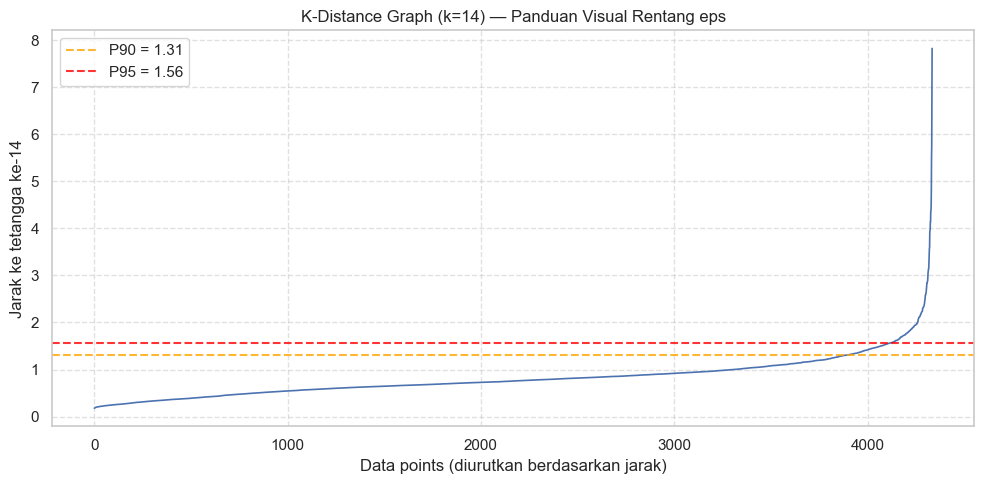

Saran rentang eps untuk grid search: 0.92 — 1.72


In [31]:
# ============================================================
# K-Distance Graph
# Digunakan untuk memperkirakan rentang eps yang wajar
# sebelum menjalankan grid search
# ============================================================
# Aturan praktis: gunakan min_samples = 2 * n_features
n_features = scaled_df.shape[1]
k_ref = 2 * n_features
print(f"n_features = {n_features}, k referensi = {k_ref}")

neighbors = NearestNeighbors(n_neighbors=k_ref)
neighbors.fit(scaled_df)
distances, _ = neighbors.kneighbors(scaled_df)
k_distances = np.sort(distances[:, k_ref - 1])  # jarak ke tetangga ke-k

plt.figure(figsize=(10, 5))
plt.plot(k_distances, linewidth=1.2)
plt.title(f'K-Distance Graph (k={k_ref}) — Panduan Visual Rentang eps')
plt.xlabel('Data points (diurutkan berdasarkan jarak)')
plt.ylabel(f'Jarak ke tetangga ke-{k_ref}')
plt.grid(True, linestyle='--', alpha=0.6)
# Tandai persentil 90 & 95 sebagai referensi 'elbow'
p90 = np.percentile(k_distances, 90)
p95 = np.percentile(k_distances, 95)
plt.axhline(p90, color='orange', linestyle='--', alpha=0.8, label=f'P90 = {p90:.2f}')
plt.axhline(p95, color='red',    linestyle='--', alpha=0.8, label=f'P95 = {p95:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Saran rentang eps untuk grid search: {p90*0.7:.2f} — {p95*1.1:.2f}")

In [32]:
import pandas as pd
from sklearn.cluster import DBSCAN

# ============================================================
# Grid Search Parameter DBSCAN (Khusus Anomaly Detection)
# Tujuan: Menyatukan Inliers menjadi 1 klaster utama, 
# sambil mendeteksi noise di rentang wajar (0.5% - 5%)
# ============================================================
print("Menjalankan grid search parameter DBSCAN (Optimasi Anomaly Detection)...")

eps_range         = [0.8, 1.0, 1.2, 1.5, 1.8]
min_samples_range = [5, 10, 15, 20]

results          = []
valid_candidates = [] # Untuk menyimpan yang lolos seleksi

for eps in eps_range:
    for min_s in min_samples_range:
        # Jalankan DBSCAN
        labels     = DBSCAN(eps=eps, min_samples=min_s).fit_predict(scaled_df)
        
        # Hitung metrik
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = int(sum(labels == -1))
        pct_noise  = (n_noise / len(labels)) * 100
        
        # Simpan semua hasil ke dalam list
        result_dict = {
            'eps': eps, 
            'min_samples': min_s,
            'n_clusters': n_clusters, 
            'n_noise': n_noise,
            'pct_noise': round(pct_noise, 2),
            'labels': labels # Simpan label untuk dipakai oleh pemenang nanti
        }
        results.append(result_dict)
        
        # JURI SELEKSI: Cek apakah memenuhi syarat Anomaly Detection
        # 1. n_clusters harus 1 (Inliers tidak terpecah)
        # 2. Persentase noise antara 0.5% sampai 5.0%
        if n_clusters == 1 and 0.5 <= pct_noise <= 5.0:
            valid_candidates.append(result_dict)

# Tampilkan seluruh hasil ke dalam tabel agar transparan
results_df = pd.DataFrame(results).drop(columns=['labels'])
print(results_df.to_string(index=False))

# ============================================================
# PENENTUAN PEMENANG (BEST PARAMETERS)
# ============================================================
print("\n" + "="*30)

if valid_candidates:
    # Jika ada yang lolos, urutkan berdasarkan pct_noise terkecil (menyelamatkan data normal terbanyak)
    valid_candidates.sort(key=lambda x: x['pct_noise'])
    best_candidate = valid_candidates[0]
    
    print("✅ KANDIDAT IDEAL DITEMUKAN!")
else:
    # FALLBACK: Jika tidak ada yang masuk rentang, cari yang n_clusters paling mendekati 1 dan noise terkecil
    print("⚠️ PERINGATAN: Tidak ada kandidat di rentang 0.5% - 5%. Menggunakan mode Fallback.")
    results.sort(key=lambda x: (x['n_clusters'], x['pct_noise']))
    best_candidate = results[0]

# Ekstrak parameter terbaik
best_eps         = best_candidate['eps']
best_min_samples = best_candidate['min_samples']
best_labels      = best_candidate['labels']

print(f"  eps          = {best_eps}")
print(f"  min_samples  = {best_min_samples}")
print(f"  n_clusters   = {best_candidate['n_clusters']}")
print(f"  n_noise      = {best_candidate['n_noise']} dari {len(best_labels)} ({best_candidate['pct_noise']}%)")
print("="*30)

# Masukkan label terbaik ke dalam kolom dataset utama
customer_df['Cluster_DBSCAN'] = best_labels

Menjalankan grid search parameter DBSCAN (Optimasi Anomaly Detection)...
 eps  min_samples  n_clusters  n_noise  pct_noise
 0.8            5           7      569      13.13
 0.8           10           3      892      20.58
 0.8           15           3     1166      26.90
 0.8           20           2     1453      33.52
 1.0            5           6      275       6.34
 1.0           10           2      402       9.27
 1.0           15           2      501      11.56
 1.0           20           2      578      13.33
 1.2            5           2      149       3.44
 1.2           10           3      211       4.87
 1.2           15           2      262       6.04
 1.2           20           2      307       7.08
 1.5            5           1       53       1.22
 1.5           10           1       72       1.66
 1.5           15           1      101       2.33
 1.5           20           1      121       2.79
 1.8            5           1       27       0.62
 1.8           10          

In [33]:
# ============================================================
# DBSCAN Final — menggunakan parameter dari grid search
# [FIX] Sebelumnya hardcode eps=1.2, min_samples=5
# Sekarang menggunakan best_eps & best_min_samples
# ============================================================
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
customer_df_log['Cluster_DBSCAN'] = dbscan_final.fit_predict(scaled_df)

# Pisahkan inliers (data bersih) dan noise (anomali)
mask_clean = customer_df_log['Cluster_DBSCAN'] != -1
mask_noise = customer_df_log['Cluster_DBSCAN'] == -1

clean_data = customer_df_log[mask_clean].drop(columns=['Cluster_DBSCAN']).copy()
noise_data = customer_df_log[mask_noise].drop(columns=['Cluster_DBSCAN']).copy()

# Scaled version untuk K-Means (tanpa kolom DBSCAN)
scaled_clean = scaled_df[mask_clean.values].copy()

print(f"Pelanggan Normal (Inliers) : {len(clean_data):>6,}  ({len(clean_data)/len(customer_df_log)*100:.1f}%)")
print(f"Pelanggan Anomali (Noise)  : {len(noise_data):>6,}  ({len(noise_data)/len(customer_df_log)*100:.1f}%)")

Pelanggan Normal (Inliers) :  4,308  (99.4%)
Pelanggan Anomali (Noise)  :     27  (0.6%)


=== Perbandingan Distribusi: Clean vs Noise (skala log) ===

  Recency:
    Clean  — median: 3.951, std: 1.334
    Noise  — median: 2.197, std: 1.854

  Frequency:
    Clean  — median: 1.099, std: 0.662
    Noise  — median: 3.045, std: 1.600

  Monetary:
    Clean  — median: 6.497, std: 1.216
    Noise  — median: 10.704, std: 2.392


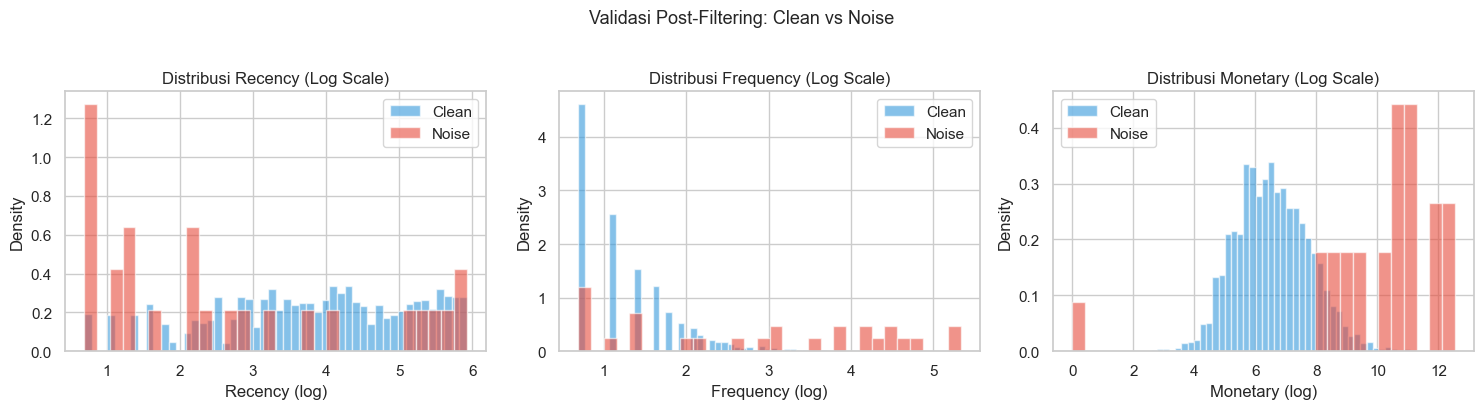

In [34]:
# ============================================================
# Validasi Post-Filtering
# Pastikan distribusi clean_data masih representatif dan
# noise_data memang berbeda secara statistik
# ============================================================
# Bandingkan statistik deskriptif (dalam skala log)
fitur_rfm = ['Recency', 'Frequency', 'Monetary']

print("=== Perbandingan Distribusi: Clean vs Noise (skala log) ===")
for fitur in fitur_rfm:
    c_med = clean_data[fitur].median()
    n_med = noise_data[fitur].median()
    c_std = clean_data[fitur].std()
    n_std = noise_data[fitur].std()
    print(f"\n  {fitur}:")
    print(f"    Clean  — median: {c_med:.3f}, std: {c_std:.3f}")
    print(f"    Noise  — median: {n_med:.3f}, std: {n_std:.3f}")

# Visualisasi distribusi Monetary (paling diskriminatif)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, fitur in enumerate(fitur_rfm):
    axes[i].hist(clean_data[fitur], bins=50, alpha=0.6, color='#3498db', label='Clean', density=True)
    axes[i].hist(noise_data[fitur], bins=30, alpha=0.6, color='#e74c3c', label='Noise', density=True)
    axes[i].set_title(f'Distribusi {fitur} (Log Scale)')
    axes[i].set_xlabel(f'{fitur} (log)')
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.suptitle('Validasi Post-Filtering: Clean vs Noise', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis (EDA)

Visualisasi untuk memahami struktur data setelah preprocessing:
1. Plot 3D RFM — sebaran pelanggan normal vs anomali
2. UMAP 2D — proyeksi non-linear, colored by DBSCAN label
3. UMAP 2D — colored by nilai fitur (Monetary, Frequency, Recency, CancelFrequency)
4. t-SNE interaktif (Plotly) — untuk eksplorasi mendalam per pelanggan

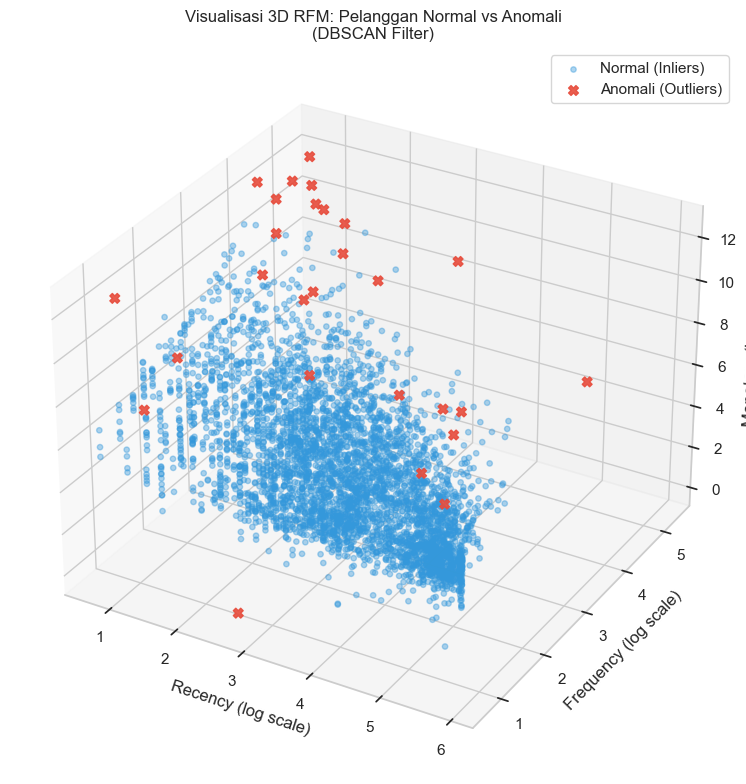

In [35]:
# ============================================================
# EDA 1: 3D Scatter Plot RFM
# Menggunakan customer_df_log (skala log) dengan label DBSCAN
# ============================================================
from mpl_toolkits.mplot3d import Axes3D

dbscan_labels = customer_df_log['Cluster_DBSCAN'].values
inliers_mask  = dbscan_labels != -1
outliers_mask = dbscan_labels == -1

fig = plt.figure(figsize=(11, 8))
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(
    customer_df_log.loc[inliers_mask,  'Recency'],
    customer_df_log.loc[inliers_mask,  'Frequency'],
    customer_df_log.loc[inliers_mask,  'Monetary'],
    c='#3498db', alpha=0.4, s=15, label='Normal (Inliers)'
)
ax.scatter(
    customer_df_log.loc[outliers_mask, 'Recency'],
    customer_df_log.loc[outliers_mask, 'Frequency'],
    customer_df_log.loc[outliers_mask, 'Monetary'],
    c='#e74c3c', alpha=0.9, s=50, marker='X', label='Anomali (Outliers)'
)

ax.set_xlabel('Recency (log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_zlabel('Monetary (log scale)')
ax.set_title('Visualisasi 3D RFM: Pelanggan Normal vs Anomali\n(DBSCAN Filter)')
ax.legend()
plt.tight_layout()
plt.show()

Menjalankan UMAP (mungkin memakan 10-30 detik)...


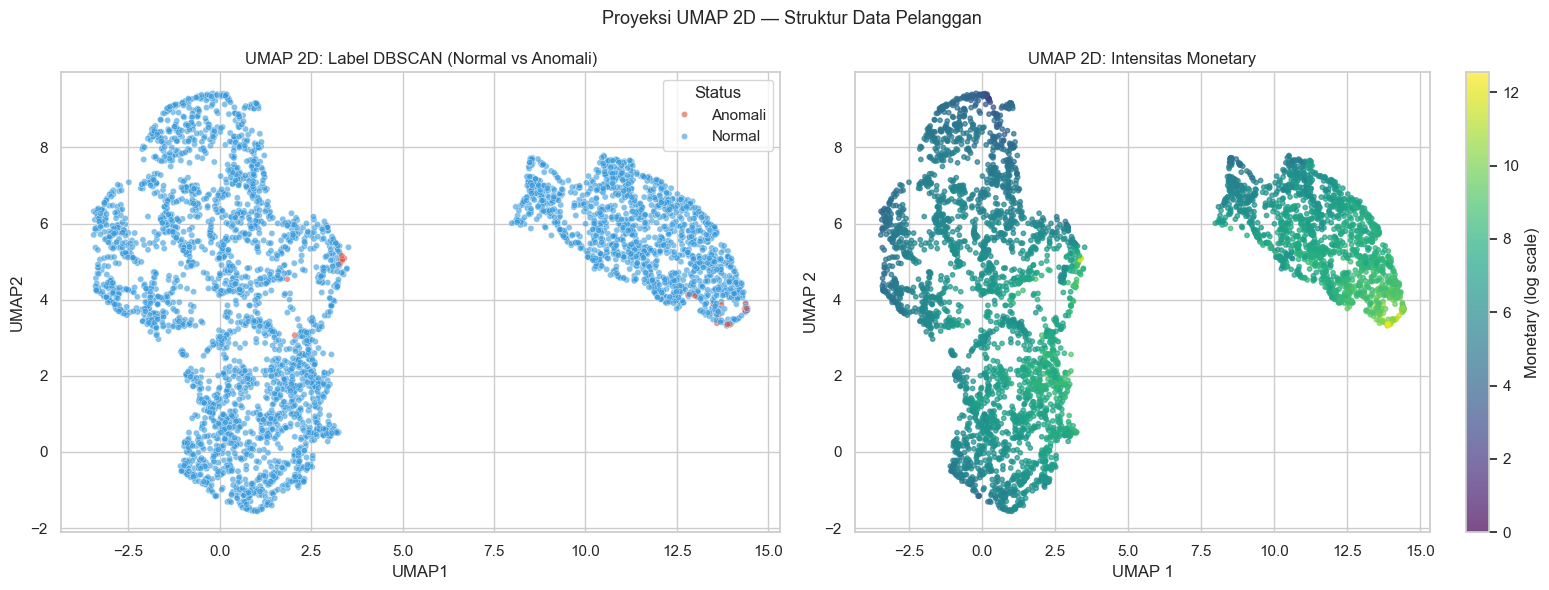

In [36]:
# ============================================================
# EDA 2 & 3: UMAP 2D
# pip install umap-learn jika belum terinstall
# ============================================================
import umap

print("Menjalankan UMAP (mungkin memakan 10-30 detik)...")
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
umap_proj    = umap_reducer.fit_transform(scaled_df)

umap_df = pd.DataFrame(umap_proj, columns=['UMAP1', 'UMAP2'], index=scaled_df.index)
umap_df['Cluster_DBSCAN'] = customer_df_log['Cluster_DBSCAN'].values
umap_df['Kategori']       = umap_df['Cluster_DBSCAN'].apply(lambda x: 'Anomali' if x == -1 else 'Normal')

# --- Plot 2a: Colored by DBSCAN label ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = {'Normal': '#3498db', 'Anomali': '#e74c3c'}
sns.scatterplot(
    data=umap_df, x='UMAP1', y='UMAP2', hue='Kategori',
    palette=palette, alpha=0.6, s=20, ax=axes[0]
)
axes[0].set_title('UMAP 2D: Label DBSCAN (Normal vs Anomali)')
axes[0].legend(title='Status')

# --- Plot 2b: Colored by Monetary (log) ---
sc = axes[1].scatter(
    umap_df['UMAP1'], umap_df['UMAP2'],
    c=customer_df_log['Monetary'].values,
    cmap='viridis', s=10, alpha=0.7
)
plt.colorbar(sc, ax=axes[1], label='Monetary (log scale)')
axes[1].set_title('UMAP 2D: Intensitas Monetary')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

plt.suptitle('Proyeksi UMAP 2D — Struktur Data Pelanggan', fontsize=13)
plt.tight_layout()
plt.show()

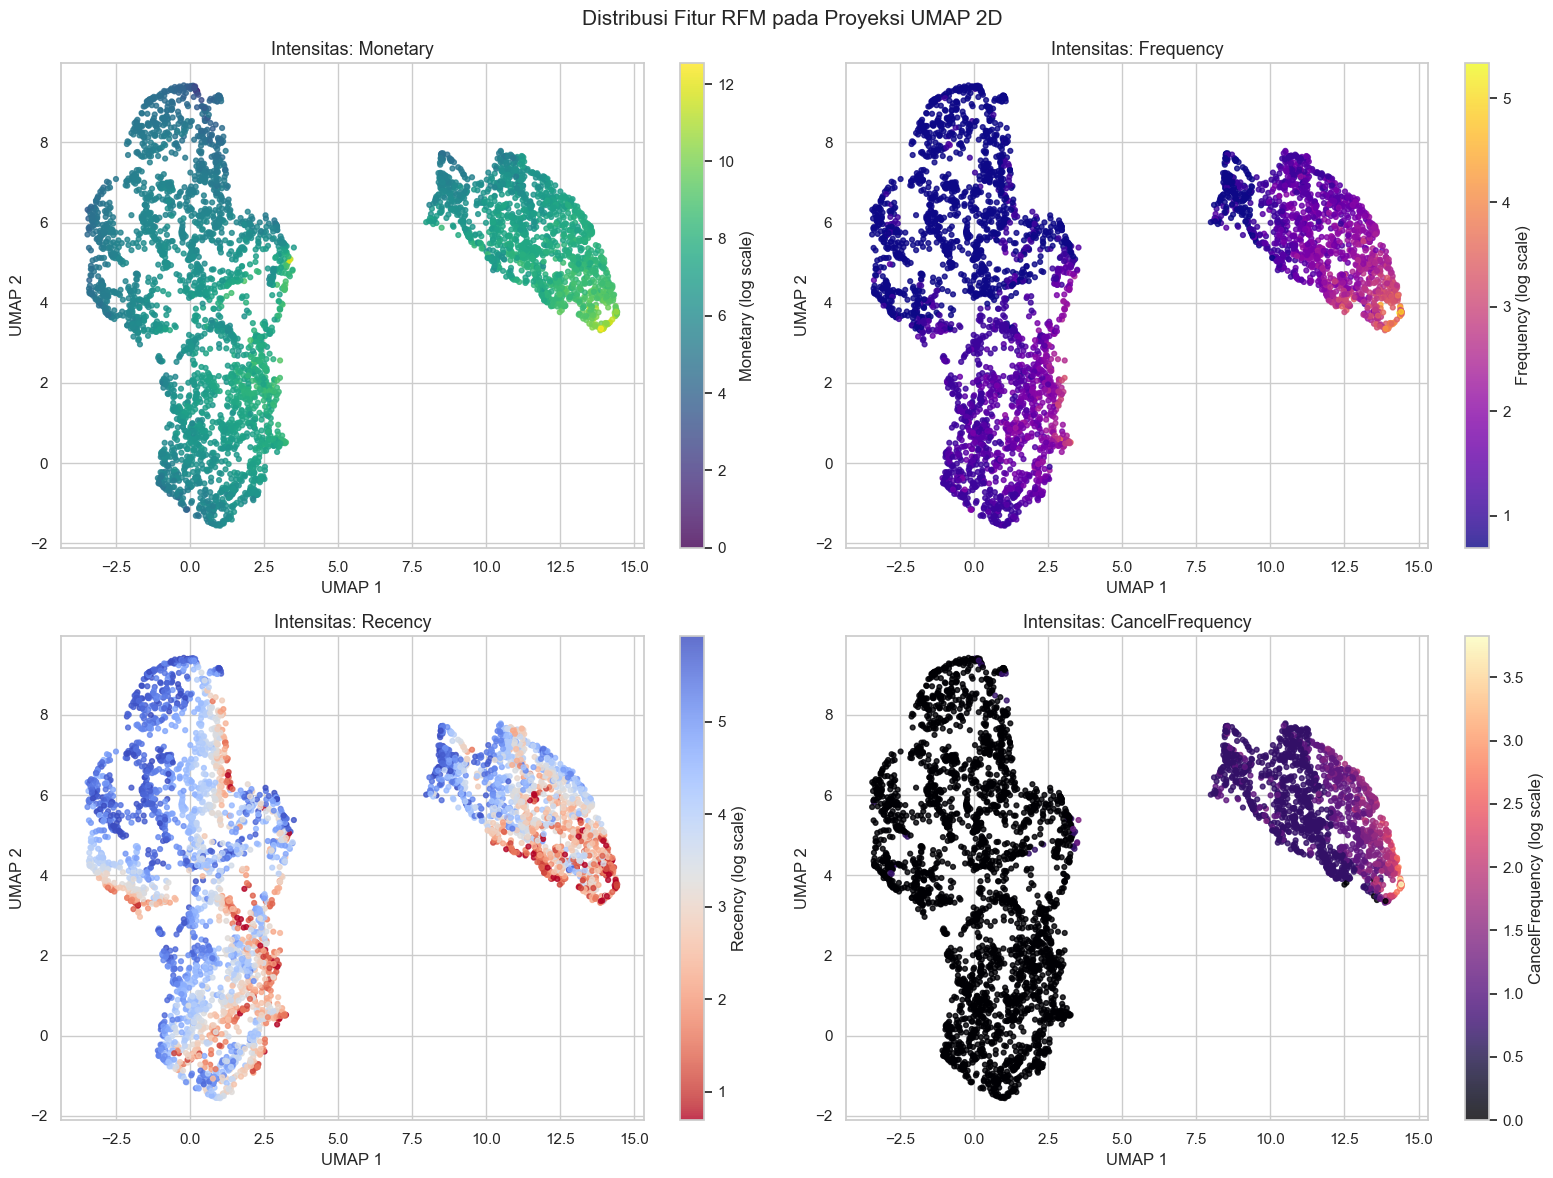

In [37]:
# ============================================================
# EDA 3: UMAP colored by 4 fitur utama (grid 2x2)
# ============================================================
fitur_utama  = ['Monetary', 'Frequency', 'Recency', 'CancelFrequency']
colormaps    = ['viridis', 'plasma', 'coolwarm_r', 'magma']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (fitur, cmap) in enumerate(zip(fitur_utama, colormaps)):
    sc = axes[i].scatter(
        umap_df['UMAP1'], umap_df['UMAP2'],
        c=customer_df_log[fitur].values,
        cmap=cmap, s=12, alpha=0.8
    )
    cbar = plt.colorbar(sc, ax=axes[i])
    cbar.set_label(f'{fitur} (log scale)')
    axes[i].set_title(f'Intensitas: {fitur}', fontsize=13)
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')

fig.suptitle('Distribusi Fitur RFM pada Proyeksi UMAP 2D', fontsize=15)
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# EDA 4: t-SNE Interaktif (Plotly)
# Hover menampilkan CustomerID + nilai RFM asli (log scale)
# ============================================================
from sklearn.manifold import TSNE
import plotly.express as px

print("Menghitung t-SNE (mungkin memakan 30-60 detik)...")
tsne = TSNE(
    n_components=2, random_state=42,
    perplexity=50, early_exaggeration=20.0,
    init='pca', learning_rate='auto'
)
tsne_results = tsne.fit_transform(scaled_df)

df_viz = pd.DataFrame({
    'Dim_1'    : tsne_results[:, 0],
    'Dim_2'    : tsne_results[:, 1],
    'Kategori' : ['Anomali' if c == -1 else 'Normal' for c in customer_df_log['Cluster_DBSCAN']],
    'CustID'   : customer_df_log.index.astype(str),
    'Monetary' : customer_df_log['Monetary'].round(3),
    'Frequency': customer_df_log['Frequency'].round(3),
    'Recency'  : customer_df_log['Recency'].round(3)
})

fig = px.scatter(
    df_viz, x='Dim_1', y='Dim_2', color='Kategori',
    color_discrete_map={'Normal': '#4292c6', 'Anomali': '#e74c3c'},
    hover_name='CustID',
    hover_data={
        'Dim_1': False, 'Dim_2': False, 'Kategori': False,
        'Monetary': ':.3f', 'Frequency': ':.3f', 'Recency': ':.3f'
    },
    title='Interactive t-SNE: Pelanggan Normal vs Anomali<br><sup>Hover untuk lihat detail CustomerID dan nilai RFM (log scale)</sup>'
)
fig.update_traces(marker=dict(size=5, opacity=0.6), selector=dict(name='Normal'))
fig.update_traces(
    marker=dict(size=6, opacity=1.0, symbol='x', line=dict(width=1, color='darkred')),
    selector=dict(name='Anomali')
)
fig.update_layout(
    plot_bgcolor='white', width=1000, height=650,
    legend_title_text='Klasifikasi DBSCAN'
)
fig.show()

Menghitung t-SNE (mungkin memakan 30-60 detik)...


## 6. Anomaly Profiling

Pelanggan yang diidentifikasi sebagai noise oleh DBSCAN dibagi ke dalam 4 persona bisnis.

**Justifikasi threshold (median):**  
Median digunakan (bukan mean) karena distribusi anomali sendiri masih skewed — beberapa outlier ekstrem akan mendistorsi mean. Median lebih robust sebagai titik pembagi untuk rule-based classification pada kelompok yang tidak normal.

Threshold Monetary  (median anomali): 44,534.30
Threshold Frequency (median anomali): 20 transaksi
Justifikasi: Median dipilih (bukan mean) karena distribusi anomali
masih skewed — median lebih robust sebagai titik pembagi.

=== DISTRIBUSI PERSONA ANOMALI ===
Persona
Indikasi Fraud / Bot (Tukang Cancel)    20
Anomali Minor (Pola Tidak Biasa)         5
Sultan (One-Time Big Spender)            1
Reseller / Grosir (B2B)                  1

Total anomali : 27


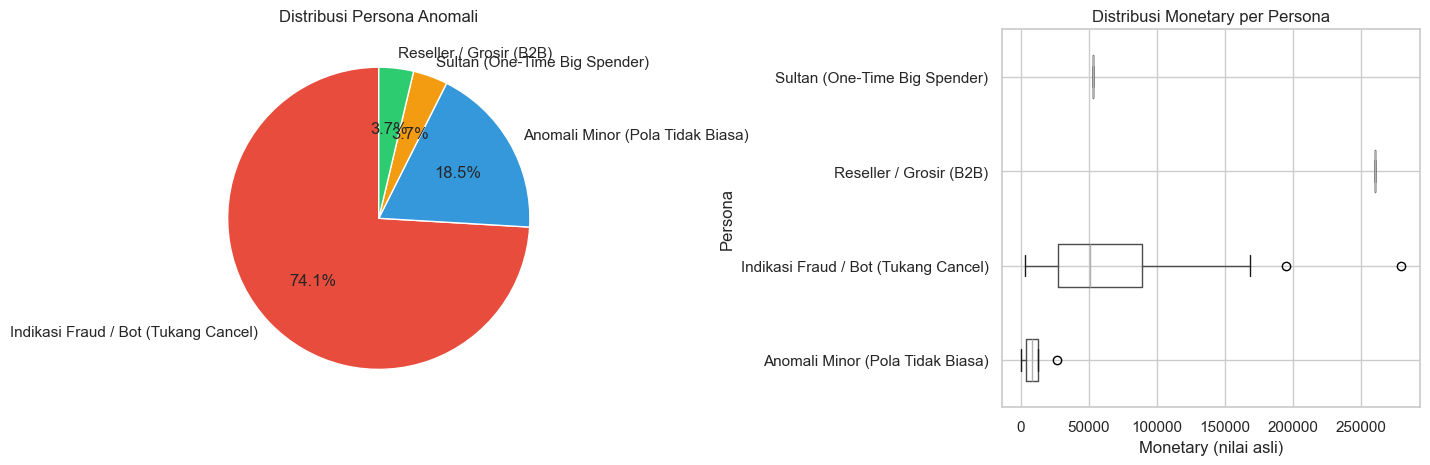

In [39]:
# ============================================================
# Anomaly Profiling — Rule-Based Persona
# Menggunakan customer_df (raw values) untuk threshold bisnis
# yang lebih mudah diinterpretasi
# ============================================================
from IPython.display import display

# Ambil data anomali dalam skala asli (lebih mudah diinterpretasi)
noise_idx  = customer_df_log[customer_df_log['Cluster_DBSCAN'] == -1].index
anomali_df = customer_df.loc[noise_idx].copy()  # nilai raw, bukan log

# Threshold berdasarkan median grup anomali
batas_monetary  = anomali_df['Monetary'].median()
batas_frequency = anomali_df['Frequency'].median()

print(f"Threshold Monetary  (median anomali): {batas_monetary:,.2f}")
print(f"Threshold Frequency (median anomali): {batas_frequency:.0f} transaksi")
print(f"Justifikasi: Median dipilih (bukan mean) karena distribusi anomali")
print(f"masih skewed — median lebih robust sebagai titik pembagi.\n")

def kategorikan_persona(row):
    """
    Prioritas klasifikasi (cascade):
    1. CancelFrequency > 0  → potensi Fraud / Bot
    2. Freq tinggi + Mon tinggi → Reseller / B2B
    3. Freq rendah + Mon tinggi → Sultan (one-time big spender)
    4. Lainnya → Anomali Minor
    """
    if row['CancelFrequency'] > 0:
        return 'Indikasi Fraud / Bot (Tukang Cancel)'
    elif row['Frequency'] > batas_frequency and row['Monetary'] > batas_monetary:
        return 'Reseller / Grosir (B2B)'
    elif row['Frequency'] <= batas_frequency and row['Monetary'] > batas_monetary:
        return 'Sultan (One-Time Big Spender)'
    else:
        return 'Anomali Minor (Pola Tidak Biasa)'

anomali_df['Persona'] = anomali_df.apply(kategorikan_persona, axis=1)

print("=== DISTRIBUSI PERSONA ANOMALI ===")
persona_count = anomali_df['Persona'].value_counts()
print(persona_count.to_string())
print(f"\nTotal anomali : {len(anomali_df):,}")

# Visualisasi pie chart persona
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    persona_count.values,
    labels=persona_count.index,
    autopct='%1.1f%%',
    colors=['#e74c3c', '#3498db', '#f39c12', '#2ecc71'],
    startangle=90
)
axes[0].set_title('Distribusi Persona Anomali')

# Boxplot Monetary per persona
anomali_df.boxplot(column='Monetary', by='Persona', ax=axes[1], vert=False)
axes[1].set_title('Distribusi Monetary per Persona')
axes[1].set_xlabel('Monetary (nilai asli)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [40]:
# Tampilkan sampel tiap persona (siap screenshot untuk slide presentasi)
kolom_tampil = ['Monetary', 'Frequency', 'Recency', 'CancelFrequency', 'AvgSpending']

for persona in anomali_df['Persona'].unique():
    subset = anomali_df[anomali_df['Persona'] == persona]
    print(f"\n>> Persona: {persona}  (n={len(subset)})")
    display(
        subset[kolom_tampil]
        .sort_values('Monetary', ascending=False)
        .head(3)
        .style.format('{:.2f}')
    )
    print('-' * 60)


>> Persona: Indikasi Fraud / Bot (Tukang Cancel)  (n=20)


,Monetary,Frequency,Recency,CancelFrequency,AvgSpending
CustomerID,,,,,
14646.000000,279138.02,73.00,2.00,1.00,135.24
17450.000000,194550.79,46.00,8.00,3.00,577.30
16446.000000,168472.50,2.00,1.00,1.00,56157.50


------------------------------------------------------------

>> Persona: Anomali Minor (Pola Tidak Biasa)  (n=5)


,Monetary,Frequency,Recency,CancelFrequency,AvgSpending
CustomerID,,,,,
16333.000000,26626.80,22.00,8.00,0.00,591.71
16000.000000,12393.70,3.00,3.00,0.00,1377.08
18139.000000,8438.34,6.00,18.00,0.00,53.07


------------------------------------------------------------

>> Persona: Sultan (One-Time Big Spender)  (n=1)


,Monetary,Frequency,Recency,CancelFrequency,AvgSpending
CustomerID,,,,,
14096.000000,53258.43,17.00,4.00,0.00,10.45


------------------------------------------------------------

>> Persona: Reseller / Grosir (B2B)  (n=1)


,Monetary,Frequency,Recency,CancelFrequency,AvgSpending
CustomerID,,,,,
18102.000000,259657.30,60.00,1.00,0.00,602.45


------------------------------------------------------------


## 7. Export Data

Tiga file di-export:
1. `clean_customer_features.csv` — data bersih (log-transformed) untuk tahap K-Means
2. `scaled_clean_features.csv` — data bersih yang sudah di-scale (untuk K-Means langsung)
3. `anomalous_customers.csv` — data anomali beserta persona untuk analisis lebih lanjut

> **Catatan:** `scaler` yang di-fit di notebook ini harus disimpan juga (menggunakan `joblib`) agar data baru dapat di-transform dengan skala yang sama saat deployment.

In [41]:
import os
os.makedirs('../data/processed', exist_ok=True)

# 1. Data bersih (log scale) — untuk inspeksi dan clustering
clean_data.to_csv('../data/processed/clean_customer_features.csv')

# 2. Data bersih (scaled) — langsung dipakai K-Means
scaled_clean.to_csv('../data/processed/scaled_clean_features.csv')

# 3. Data anomali + persona
anomali_df.to_csv('../data/processed/anomalous_customers.csv')

# 4. Simpan scaler untuk deployment
import joblib
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/standard_scaler.pkl')

print("=== Export Selesai ===")
print(f"  clean_customer_features.csv  : {len(clean_data):,} baris x {clean_data.shape[1]} kolom")
print(f"  scaled_clean_features.csv    : {len(scaled_clean):,} baris x {scaled_clean.shape[1]} kolom")
print(f"  anomalous_customers.csv      : {len(anomali_df):,} baris x {anomali_df.shape[1]} kolom")
print(f"  standard_scaler.pkl          : tersimpan di ../models/")
print("\nPreprocessing selesai. Data siap untuk tahap K-Means clustering.")

=== Export Selesai ===
  clean_customer_features.csv  : 4,308 baris x 7 kolom
  scaled_clean_features.csv    : 4,308 baris x 7 kolom
  anomalous_customers.csv      : 27 baris x 9 kolom
  standard_scaler.pkl          : tersimpan di ../models/

Preprocessing selesai. Data siap untuk tahap K-Means clustering.
